In [1]:
import csv
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## Matrix calculations

def ZeroClip(x):
    x *= 1e8
    x = np.round(x)
    x /= 1e8
    return x

def symmetrize(A):
    return 0.5 * (A + A.T)


def sqrtm_psd(A, eps=1e-12):
    """
    Symmetric positive-semidefinite matrix square root.
    """
    A = symmetrize(A)
    vals, vecs = np.linalg.eigh(A)
    vals = np.clip(vals, 0.0, None)
    return vecs @ np.diag(np.sqrt(vals)) @ vecs.T


def inv_sqrtm_psd(A, eps = 1e-12):
    """
    Inverse square root for symmetric PSD matrix.
    Small eigenvalues are regularized.
    """
    A = symmetrize(A)
    vals, vecs = np.linalg.eigh(A)
    vals = np.clip(vals, eps, None)
    return vecs @ np.diag(1.0 / np.sqrt(vals)) @ vecs.T


def nearest_rotation_matrix(R):
    """
    Project a 3x3 matrix onto the nearest proper rotation matrix SO(3).
    """
    U, _, Vt = np.linalg.svd(R)
    Rn = U @ Vt
    if np.linalg.det(Rn) < 0:
        U[:, -1] *= -1
        Rn = U @ Vt
    return Rn

In [3]:
## Basis and labels

def pauli_matrices():
    sigma0 = np.array([[1, 0], [0, 1]], dtype=complex)
    sigma1 = np.array([[1, 0], [0, -1]], dtype=complex)   # H/V
    sigma2 = np.array([[0, 1], [1, 0]], dtype=complex)    # D/A
    sigma3 = np.array([[0, -1j], [1j, 0]], dtype=complex) # R/L convention
    return [sigma0, sigma1, sigma2, sigma3]


STOKES = {
    "H": np.array([1,  1,  0,  0], dtype=float),
    "V": np.array([1, -1,  0,  0], dtype=float),
    "D": np.array([1,  0,  1,  0], dtype=float),
    "A": np.array([1,  0, -1,  0], dtype=float),
    "R": np.array([1,  0,  0,  1], dtype=float),
    "L": np.array([1,  0,  0, -1], dtype=float),
    }

def basis_pair(label):
    if label in ["H", "V"]:
        return ("H", "V")
    if label in ["D", "A"]:
        return ("D", "A")
    if label in ["R", "L"]:
        return ("R", "L")
    raise ValueError(label)

LABELS = ["H", "V", "D", "A", "R", "L"]

ANALYZER_PAIRS = [("H", "V"), ("D", "A"), ("R", "L")]

In [4]:
## Data file load

def load_36_counts_csv(path, labels=LABELS):
    """
    Load 36 coincidence counts N_WU from CSV.

    Supported CSV formats:

    Format A: 6 x 6 numeric matrix
        rows: photon-1 projection W = H,V,D,A,R,L
        columns: photon-2 projection U = H,V,D,A,R,L

        Example:
            123, 120, ...
            ...

    Format B: 7 x 7 table with row/column labels
            ,H,V,D,A,R,L
        H,  NHH,NHV,NHD,NHA,NHR,NHL
        V,  NVH,NVV,...

    Format C: 36 rows, 3 columns
        W,U,count
        H,H,123
        H,V,120
        ...

    Format D: 36 rows, 2 columns
        label,count
        HH,123
        HV,120
        ...

    Returns
    -------
    N : dict
        N[(W,U)] = coincidence count
    C : np.ndarray, shape (6,6)
        C[i,j] = N[(labels[i], labels[j])]
    """

    with open(path, "r", newline="") as f:
        rows = list(csv.reader(f))

    # Remove empty rows and strip spaces
    rows = [[cell.strip() for cell in row] for row in rows if len(row) > 0]
    rows = [row for row in rows if any(cell != "" for cell in row)]

    # Try to remove header-like row for 36-row formats
    def is_float(x):
        try:
            float(x)
            return True
        except Exception:
            return False

    # ---------- Format B: 7x7 labeled matrix ----------
    if len(rows) >= 7 and len(rows[0]) >= 7:
        header = rows[0]
        if all(x in labels or x == "" for x in header[:7]):
            col_labels = header[1:7]
            if set(col_labels) == set(labels):
                C = np.zeros((6, 6), dtype=float)
                for i in range(6):
                    row_label = rows[i + 1][0]
                    if row_label not in labels:
                        raise ValueError("Invalid row label in labeled 7x7 CSV.")
                    for j in range(6):
                        C[labels.index(row_label), labels.index(col_labels[j])] = float(rows[i + 1][j + 1])
                N = {(labels[i], labels[j]): C[i, j] for i in range(6) for j in range(6)}
                return N, C

    # ---------- Format A: 6x6 numeric matrix ----------
    if len(rows) == 6 and all(len(row) >= 6 for row in rows):
        if all(is_float(rows[i][j]) for i in range(6) for j in range(6)):
            C = np.array([[float(rows[i][j]) for j in range(6)] for i in range(6)], dtype=float)
            N = {(labels[i], labels[j]): C[i, j] for i in range(6) for j in range(6)}
            return N, C

    # ---------- Format C or D: row list ----------
    # Remove header if first row is non-data
    data_rows = rows[:]
    if len(data_rows) > 0:
        first = data_rows[0]
        if len(first) >= 2 and not is_float(first[-1]):
            data_rows = data_rows[1:]

    N = {}

    for row in data_rows:
        # Format C: W,U,count
        if len(row) >= 3 and row[0] in labels and row[1] in labels and is_float(row[2]):
            W, U, val = row[0], row[1], float(row[2])
            N[(W, U)] = val

        # Format D: label,count; e.g. HH,123
        elif len(row) >= 2 and len(row[0]) == 2 and row[0][0] in labels and row[0][1] in labels and is_float(row[1]):
            W, U, val = row[0][0], row[0][1], float(row[1])
            N[(W, U)] = val

    missing = [(W, U) for W in labels for U in labels if (W, U) not in N]
    if missing:
        raise ValueError(f"Missing coincidence counts for: {missing}")

    C = np.array([[N[(W, U)] for U in labels] for W in labels], dtype=float)
    return N, C

In [5]:
## Hermitian matrix corresponding Mueller matrix
def choi_from_mueller(M):
    """
    Construct Choi matrix from Mueller matrix.

    Convention:
        E(sigma_j) = sum_i M[i,j] sigma_i

    Choi:
        J = 1/2 sum_{i,j} M[i,j] sigma_j^T tensor sigma_i

    For M[0,0] = 1, Tr(J) = 2.
    """

    sig = pauli_matrices()
    J = np.zeros((4, 4), dtype=complex)

    for i in range(4):
        for j in range(4):
            J += 0.5 * M[i, j] * np.kron(sig[j].T, sig[i])

    J = 0.5 * (J + J.conj().T)
    return J


def mueller_from_choi(J):
    """
    Recover Mueller matrix from Choi matrix.

    Since:
        J = 1/2 sum M[i,j] sigma_j^T tensor sigma_i

    Then:
        M[i,j] = 1/2 Tr[J (sigma_j^T tensor sigma_i)].
    """

    sig = pauli_matrices()
    M = np.zeros((4, 4), dtype=float)

    for i in range(4):
        for j in range(4):
            A = np.kron(sig[j].T, sig[i])
            M[i, j] = 0.5 * np.real(np.trace(J @ A))

    return M


def project_choi_psd_trace2(J, eps=1e-12):
    """
    Project an arbitrary Hermitian Choi matrix to PSD with Tr(J)=2.
    Used only for initialization.
    """

    J = 0.5 * (J + J.conj().T)
    vals, vecs = np.linalg.eigh(J)
    vals = np.clip(vals, eps, None)
    Jp = vecs @ np.diag(vals) @ vecs.conj().T
    Jp = 2.0 * Jp / np.real(np.trace(Jp))
    return 0.5 * (Jp + Jp.conj().T)


def params_to_lower_triangular(x):
    """
    Convert 16 real parameters to a 4x4 complex lower-triangular matrix T.

    Diagonal elements are positive via exp().
    Lower off-diagonal elements are complex.
    """

    x = np.asarray(x, dtype=float)
    if x.size != 16:
        raise ValueError("x must have length 16.")

    T = np.zeros((4, 4), dtype=complex)

    # 4 real diagonal parameters
    T[0, 0] = np.exp(x[0])
    T[1, 1] = np.exp(x[1])
    T[2, 2] = np.exp(x[2])
    T[3, 3] = np.exp(x[3])

    # 6 complex lower-triangular entries = 12 real parameters
    idx = 4
    for r in range(1, 4):
        for c in range(r):
            T[r, c] = x[idx] + 1j * x[idx + 1]
            idx += 2

    return T


def lower_triangular_to_params(T, eps=1e-12):
    """
    Convert a 4x4 complex lower-triangular matrix T to 16 real parameters.
    """

    x = np.zeros(16, dtype=float)

    for k in range(4):
        x[k] = np.log(max(np.real(T[k, k]), eps))

    idx = 4
    for r in range(1, 4):
        for c in range(r):
            x[idx] = np.real(T[r, c])
            x[idx + 1] = np.imag(T[r, c])
            idx += 2

    return x


def choi_from_params(x):
    """
    PSD and trace-normalized Choi matrix.

        J = 2 T T^dagger / Tr(T T^dagger)

    This automatically enforces:
        J >= 0
        Tr(J) = 2
        M[0,0] = 1
    """

    T = params_to_lower_triangular(x)
    J = T @ T.conj().T
    tr = np.real(np.trace(J))

    if tr <= 0:
        raise ValueError("Invalid Cholesky parametrization.")

    J = 2.0 * J / tr
    J = 0.5 * (J + J.conj().T)
    return J

def initial_params_from_direct_mueller(M_direct):
    """
    Use direct-inversion Mueller matrix as an initial guess.

    Steps:
        M_direct -> Choi
        project Choi to PSD, Tr=2
        Cholesky factor -> params
    """

    J0 = choi_from_mueller(M_direct)
    J0 = project_choi_psd_trace2(J0)

    # Add tiny diagonal jitter for Cholesky
    jitter = 1e-10 * np.eye(4)
    T0 = np.linalg.cholesky(J0 + jitter)

    return lower_triangular_to_params(T0)

def predicted_probabilities_from_mueller(M, labels=LABELS, eps=1e-12):
    """
    p[W,U] = 1/2 s_U^T M s_W

    Returns a dictionary p[(W,U)].
    """

    p = {}

    for W in labels:
        s_in = STOKES[W]

        for U in labels:
            s_out = STOKES[U]
            val = 0.5 * float(s_out @ M @ s_in)

            # Numerical protection.
            # If the model is physical, val should be nonnegative
            # for physical input/output states.
            p[(W, U)] = max(val, eps)

    return p

## Probability distribution model

def binomial_nll_for_mueller(M, counts, labels=LABELS, eps=1e-12):
    """
    Pair-normalized likelihood.

    For each effective input W and each analyzer basis pair (U1,U2),
    use only the relative splitting between the two orthogonal outcomes.

    This reduces sensitivity to basis-dependent throughput, integration
    time drift, and source brightness drift.
    """
    p = predicted_probabilities_from_mueller(M, labels=labels, eps=eps)

    nll = 0.0

    for W in labels:
        for U1, U2 in ANALYZER_PAIRS:
            c1 = float(counts[(W, U1)])
            c2 = float(counts[(W, U2)])

            p1 = max(p[(W, U1)], eps)
            p2 = max(p[(W, U2)], eps)

            q1 = p1 / max(p1 + p2, eps)
            q2 = p2 / max(p1 + p2, eps)

            nll -= c1 * np.log(max(q1, eps)) + c2 * np.log(max(q2, eps))

    return nll

def binomial_nll_physical_mueller(x, counts, labels=LABELS, eps=1e-12):
    J = choi_from_params(x)
    M = mueller_from_choi(J)
    M = M / M[0, 0]
    return binomial_nll_for_mueller(M, counts, labels=labels, eps=eps)


# def poisson_nll_profile_scale(x, counts, labels=LABELS, eps=1e-12):
#     """
#     Negative Poisson log-likelihood with profiled global scale A.

#     counts[(W,U)] = measured coincidence count.

#     Model:
#         mu_WU = A * p_WU(M)

#     The optimum scale for a fixed M is:
#         A_hat = sum(counts) / sum(p)
#     """

#     J = choi_from_params(x)
#     M = mueller_from_choi(J)

#     p = predicted_probabilities_from_mueller(M, labels=labels, eps=eps)

#     c_sum = 0.0
#     p_sum = 0.0

#     for W in labels:
#         for U in labels:
#             c = float(counts[(W, U)])
#             c_sum += c
#             p_sum += p[(W, U)]

#     A_hat = c_sum / max(p_sum, eps)

#     nll = 0.0
#     for W in labels:
#         for U in labels:
#             c = float(counts[(W, U)])
#             mu = max(A_hat * p[(W, U)], eps)
#             nll += mu - c * np.log(mu)

#     return nll

In [6]:
## Initial Mueller matrix construction from counts - before estimation

def mueller_from_phi_plus_counts(N, normalize=True):
    """
    Compute Mueller matrix from 36 coincidence counts N_WU
    for the |Phi+> Bell-state nonclassical Mueller polarimetry case.

    N[(W,U)]:
        W = photon 1 projection
        U = photon 2 projection

    This implements Table 3 of the paper.

    Returns
    -------
    M : np.ndarray, shape (4,4)
        Mueller matrix. If normalize=True, M[0,0] = 1.
    """

    def n(W, U):
        return float(N[(W, U)])

    m = np.zeros((4, 4), dtype=float)

    # Row 1
    m[0, 0] = n("H", "H") + n("H", "V") + n("V", "H") + n("V", "V")
    m[0, 1] = n("H", "H") + n("H", "V") - n("V", "H") - n("V", "V")
    m[0, 2] = n("D", "H") + n("D", "V") - n("A", "H") - n("A", "V")
    m[0, 3] = n("L", "H") + n("L", "V") - n("R", "H") - n("R", "V")

    # Row 2
    m[1, 0] = n("H", "H") + n("V", "H") - n("H", "V") - n("V", "V")
    m[1, 1] = n("H", "H") + n("V", "V") - n("V", "H") - n("H", "V")
    m[1, 2] = n("D", "H") + n("A", "V") - n("A", "H") - n("D", "V")
    m[1, 3] = n("L", "H") + n("R", "V") - n("R", "H") - n("L", "V")

    # Row 3
    m[2, 0] = n("H", "D") + n("V", "D") - n("V", "A") - n("H", "A")
    m[2, 1] = n("H", "D") + n("V", "A") - n("V", "D") - n("H", "A")
    m[2, 2] = n("A", "A") + n("D", "D") - n("D", "A") - n("A", "D")
    m[2, 3] = n("L", "D") + n("R", "A") - n("L", "A") - n("R", "D")

    # Row 4
    m[3, 0] = n("H", "R") + n("V", "R") - n("H", "L") - n("V", "L")
    m[3, 1] = n("H", "R") + n("V", "L") - n("V", "R") - n("H", "L")
    m[3, 2] = n("A", "L") + n("D", "R") - n("A", "R") - n("D", "L")
    m[3, 3] = n("R", "L") + n("L", "R") - n("L", "L") - n("R", "R")

    if normalize:
        if abs(m[0, 0]) < 1e-15:
            raise ValueError("m11 is zero or too small; cannot normalize Mueller matrix.")
        m = m / m[0, 0]

    return m

def flip_label(label):
    pair = {
        "H": "V", "V": "H",
        "D": "A", "A": "D",
        "R": "L", "L": "R",
    }
    return pair[label]


def basis_of_label(label):
    if label in ["H", "V"]:
        return "HV"
    if label in ["D", "A"]:
        return "DA"
    if label in ["R", "L"]:
        return "RL"
    raise ValueError(f"Unknown polarization label: {label}")


def bell_correlation_rules(bell_state):
    """
    Returns whether photon-1 and photon-2 projections are correlated
    in each basis.

    True  = correlated
    False = anticorrelated
    """
    rules = {
        "Phi+": {"HV": True,  "DA": True,  "RL": False},
        "Phi-": {"HV": True,  "DA": False, "RL": True},
        "Psi+": {"HV": False, "DA": True,  "RL": True},
        "Psi-": {"HV": False, "DA": False, "RL": False},
    }

    if bell_state not in rules:
        raise ValueError(
            "bell_state must be one of: 'Phi+', 'Phi-', 'Psi+', 'Psi-'"
        )

    return rules[bell_state]


def remap_counts_to_phi_plus_convention(N, bell_state):
    """
    Convert counts measured with a chosen Bell state into the effective
    Phi+ Table-3 convention by relabeling photon-1 projection labels.

    N[(W,U)]:
        W = photon 1 projection
        U = photon 2 projection

    Returns
    -------
    N_eff : dict
        Counts that can be passed into mueller_from_phi_plus_counts().
    """

    rules = bell_correlation_rules(bell_state)

    N_eff = {}

    for W_eff in LABELS:
        b = basis_of_label(W_eff)

        # Phi+ convention:
        # HV and DA correlated, RL anticorrelated.
        phi_plus_corr = {"HV": True, "DA": True, "RL": False}[b]

        target_corr = rules[b]

        # If target Bell state has the same correlation as Phi+ in this basis,
        # use the same photon-1 label. Otherwise flip photon-1 label.
        if target_corr == phi_plus_corr:
            W_meas = W_eff
        else:
            W_meas = flip_label(W_eff)

        for U in LABELS:
            N_eff[(W_eff, U)] = N[(W_meas, U)]

    return N_eff


# def mueller_from_bell_counts(N, bell_state="Phi+", normalize=True):
#     """
#     General Bell-state version.

#     bell_state:
#         'Phi+', 'Phi-', 'Psi+', 'Psi-'
#     """

#     N_eff = remap_counts_to_phi_plus_convention(N, bell_state)

#     return mueller_from_phi_plus_counts(N_eff, normalize = normalize)


In [7]:
## Maximum-likelihood estimation

def mle_physical_mueller_from_counts(
    N,
    bell_state = "Phi+",
    labels = LABELS,
    maxiter = 5000,
    verbose = False,
):
    """
    Maximum-likelihood physical Mueller matrix estimation.

    Parameters
    ----------
    N : dict
        Raw counts N[(W,U)].
        W = photon 1 projection.
        U = photon 2 projection.

    bell_state : str
        'Phi+', 'Phi-', 'Psi+', or 'Psi-'.

    Returns
    -------
    result : dict
        M_mle : physical Mueller matrix
        J_mle : PSD Choi matrix
        M_direct : direct Table-3 Mueller matrix
        eigvals_choi : eigenvalues of J_mle
        success : optimizer success flag
        message : optimizer message
        nll : final negative log-likelihood
    """

    # Remap counts to the Phi+ effective convention if using other Bell states.
    N_eff = remap_counts_to_phi_plus_convention(N, bell_state)

    # Direct estimate used only as initial guess.
    M_direct = mueller_from_phi_plus_counts(N_eff, normalize=True)
    # M_direct = mueller_from_bell_counts(N_eff, bell_state = "Psi+", normalize=True)

    x0 = initial_params_from_direct_mueller(M_direct)

    opt = minimize(
        binomial_nll_physical_mueller,
        x0,
        args=(N_eff, labels),
        method="L-BFGS-B",
        options={
            "maxiter": maxiter,
            "ftol": 1e-12,
            "gtol": 1e-8,
        },
    )

    if verbose:
        print(opt)

    J_mle = choi_from_params(opt.x)
    M_mle = mueller_from_choi(J_mle)

    # Normalize tiny numerical drift
    M_mle = M_mle / M_mle[0, 0]

    eigvals = np.linalg.eigvalsh(J_mle)

    return {
        "M_mle": M_mle,
        "J_mle": J_mle,
        "M_direct": M_direct,
        "eigvals_choi": eigvals,
        "success": opt.success,
        "message": opt.message,
        "nll": opt.fun,
    }

In [8]:
# ============================================================
# 4. Lu-Chipman-style polar decomposition
# ============================================================

def lu_chipman_decomposition(M, eps=1e-12):
    """
    Decompose Mueller matrix into:
        M ≈ M_delta @ M_R @ M_D

    where
        M_D     : diattenuation matrix
        M_R     : retardance matrix
        M_delta : depolarization / polarizance-like matrix

    Note:
        The paper writes the conceptual decomposition as M = D R P.
        In many Mueller-polarimetry references, the forward Lu-Chipman
        decomposition is written as M = M_delta M_R M_D.
        This function returns the physically standard components with names.

    Returns
    -------
    result : dict
        {
            "M": normalized Mueller matrix,
            "diattenuation_matrix": M_D,
            "retardance_matrix": M_R,
            "polarizance_matrix": M_delta,
            "diattenuation_vector": d,
            "polarizance_vector": p,
            "diattenuation_magnitude": Dmag,
            "depolarization_index_delta": Delta
        }
    """

    M = np.array(M, dtype=float).copy()

    if abs(M[0, 0]) < eps:
        raise ValueError("M[0,0] is zero or too small.")
    M = M / M[0, 0]

    # Diattenuation vector from first row
    d = M[0, 1:4].copy()
    Dmag = np.linalg.norm(d)

    # Avoid numerical problems for nearly ideal polarizers
    Dclip = min(Dmag, 1.0 - 1e-10)

    if Dmag > eps:
        dhat = d / Dmag
        sqrt_term = np.sqrt(max(0.0, 1.0 - Dclip**2))
        mD = sqrt_term * np.eye(3) + (1.0 - sqrt_term) * np.outer(dhat, dhat)
    else:
        mD = np.eye(3)

    M_D = np.eye(4)
    M_D[0, 1:4] = d
    M_D[1:4, 0] = d
    M_D[1:4, 1:4] = mD

    # Remove diattenuator from the right
    # Use pseudo-inverse to handle highly diattenuating cases.
    M_prime = M @ np.linalg.pinv(M_D)

    # M_prime ≈ M_delta @ M_R
    p_delta = M_prime[1:4, 0].copy()
    A = M_prime[1:4, 1:4].copy()

    # Left polar decomposition:
    # A = m_delta @ R
    m_delta = sqrtm_psd(A @ A.T, eps=eps)
    R3 = np.linalg.pinv(m_delta) @ A
    R3 = nearest_rotation_matrix(R3)

    M_R = np.eye(4)
    M_R[1:4, 1:4] = R3

    M_delta = np.eye(4)
    M_delta[1:4, 0] = p_delta
    M_delta[1:4, 1:4] = m_delta

    # Polarizance vector of original M
    p = M[1:4, 0].copy()

    # Paper-style depolarization indicator:
    # Delta = 1 - |Tr(P)-1|/3, where P here corresponds to M_delta.
    Delta = 1.0 - abs(np.trace(M_delta) - 1.0) / 3.0

    return {
        "M": M,
        "diattenuation_matrix": M_D,
        "retardance_matrix": M_R,
        "polarizance_matrix": M_delta,
        "diattenuation_vector": d,
        "polarizance_vector": p,
        "diattenuation_magnitude": Dmag,
        "depolarization_index_delta": Delta,
    }

In [9]:
# ============================================================
# 5. Retardance, birefringence, and optical-axis extraction
# ============================================================

def retardance_axis_from_retarder(M_R, wavelength_m=None, thickness_m=None, eps=1e-12):
    """
    Extract retardance and optical axis information from the retardance matrix M_R.

    Parameters
    ----------
    M_R : np.ndarray, shape (4,4)
        Retardance Mueller matrix.
    wavelength_m : float or None
        Optical wavelength in meters.
    thickness_m : float or None
        Sample thickness in meters.

    Returns
    -------
    info : dict
        retardance_rad
        retardance_deg
        poincare_axis
        linear_retarder_axis_deg
        birefringence_abs
        notes

    Notes
    -----
    The 3x3 block of a pure retarder is a rotation on the Poincare sphere.
    Its rotation angle is the retardance magnitude.

    For a purely linear retarder:
        Poincare axis ≈ (cos 2theta, sin 2theta, 0)
    so
        theta = 0.5 atan2(axis_S2, axis_S1)

    Absolute fast/slow labeling requires a sign convention and calibration.
    Mueller intensity data alone usually gives the magnitude robustly,
    while fast-vs-slow assignment is convention-dependent.
    """

    R = np.array(M_R[1:4, 1:4], dtype=float)
    R = nearest_rotation_matrix(R)

    cos_delta = (np.trace(R) - 1.0) / 2.0
    cos_delta = np.clip(cos_delta, -1.0, 1.0)
    delta = np.arccos(cos_delta)

    if abs(np.sin(delta)) > eps:
        axis = np.array([
            R[2, 1] - R[1, 2],
            R[0, 2] - R[2, 0],
            R[1, 0] - R[0, 1],
        ]) / (2.0 * np.sin(delta))
        axis = axis / np.linalg.norm(axis)
    else:
        axis = np.array([np.nan, np.nan, np.nan])

    # Linear retarder axis angle on lab H/V basis
    # valid when axis[2] ≈ 0
    if np.all(np.isfinite(axis)):
        linear_axis_rad = 0.5 * np.arctan2(axis[1], axis[0])
        linear_axis_deg = np.degrees(linear_axis_rad)

        # Map to [-90, 90)
        while linear_axis_deg >= 90.0:
            linear_axis_deg -= 180.0
        while linear_axis_deg < -90.0:
            linear_axis_deg += 180.0
    else:
        linear_axis_deg = np.nan

    birefringence_abs = None
    if wavelength_m is not None and thickness_m is not None:
        if thickness_m <= 0:
            raise ValueError("thickness_m must be positive.")
        birefringence_abs = delta * wavelength_m / (2.0 * np.pi * thickness_m)

    notes = (
        "retardance_rad is the phase retardance magnitude. "
        "birefringence_abs = |Delta n| if wavelength_m and thickness_m are supplied. "
        "linear_retarder_axis_deg is meaningful when the Poincare axis S3 component is near zero. "
        "Fast/slow-axis assignment requires an external sign convention or calibration."
    )

    return {
        "retardance_rad": delta,
        "retardance_deg": np.degrees(delta),
        "poincare_axis": axis,
        "linear_retarder_axis_deg": linear_axis_deg,
        "birefringence_abs": birefringence_abs,
        "notes": notes,
    }

In [10]:
def analyze_nonclassical_mueller_csv(
    csv_path,
    wavelength_nm=None,
    length_m=None,
    labels=LABELS,
    bell_state="Phi+",
    use_mle=True,
):
    N, C = load_36_counts_csv(csv_path, labels = labels)

    if use_mle:
        mle_result = mle_physical_mueller_from_counts(
            N,
            bell_state=bell_state,
            labels=labels,
            maxiter=5000,
            verbose=False,
        )

        M = mle_result["M_mle"]

    else:
        N_eff = remap_counts_to_phi_plus_convention(N, bell_state)
        M = mueller_from_phi_plus_counts(N_eff, normalize=True)
        mle_result = None

    decomp = lu_chipman_decomposition(M)

    wavelength_m = None if wavelength_nm is None else wavelength_nm * 1e-9
    length = None if length_m is None else length_m

    ret_info = retardance_axis_from_retarder(
        decomp["retardance_matrix"],
        wavelength_m = wavelength_m,
        thickness_m = length,
    )

    return {
        "raw_counts_matrix_6x6": C,
        "bell_state": bell_state,
        "used_mle": use_mle,
        "mle_result": mle_result,

        "total_mueller_matrix": decomp["M"],
        "diattenuation_matrix": decomp["diattenuation_matrix"],
        "retardance_matrix": decomp["retardance_matrix"],
        "polarizance_matrix": decomp["polarizance_matrix"],

        "diattenuation_vector": decomp["diattenuation_vector"],
        "polarizance_vector": decomp["polarizance_vector"],
        "diattenuation_magnitude": decomp["diattenuation_magnitude"],
        "depolarization_index_delta": decomp["depolarization_index_delta"],

        "retardance_info": ret_info,
    }

In [ ]:
# ============================================================
# 7. Example usage
# ============================================================
Data_file_name = "Mueller_sample_20260428"
if __name__ == "__main__":
    # csv_path = "coincidence_counts.csv"
    csv_path = Data_file_name + ".csv"
    # Example:
    # wavelength_nm = 1550 for the experiment in the paper.
    # length_m should be supplied only if the sample thickness is known.
    result = analyze_nonclassical_mueller_csv(
        csv_path,
        wavelength_nm = 1550.0,
        length_m = 10,
        labels = LABELS,
        bell_state = "Psi+",
        use_mle = True,
    )

    print("\nTotal Mueller matrix M:")
    print(np.array2string(result["total_mueller_matrix"], precision=5, suppress_small=True))

    print("\nDiattenuation matrix M_D:")
    print(np.array2string(result["diattenuation_matrix"], precision=5, suppress_small=True))

    print("\nRetardance matrix M_R:")
    print(np.array2string(result["retardance_matrix"], precision=5, suppress_small=True))

    print("\nPolarizance / depolarization matrix M_delta:")
    print(np.array2string(result["polarizance_matrix"], precision=5, suppress_small=True))

    print("\nDiattenuation magnitude:")
    print(result["diattenuation_magnitude"])

    print("\nDepolarization index Delta:")
    print(result["depolarization_index_delta"])

    print("\nRetardance / axis information:")
    for k, v in result["retardance_info"].items():
        print(f"{k}: {v}")


Total Mueller matrix M:
[[ 1.      -0.00757  0.00221 -0.00119]
 [ 0.00212  0.22535  0.14604 -0.18326]
 [ 0.00156 -0.0631  -0.23944 -0.20079]
 [-0.01788  0.28204 -0.18917  0.11556]]

Diattenuation matrix M_D:
[[ 1.      -0.00757  0.00221 -0.00119]
 [-0.00757  1.      -0.00001  0.     ]
 [ 0.00221 -0.00001  0.99997 -0.     ]
 [-0.00119  0.      -0.       0.99997]]

Retardance matrix M_R:
[[ 1.       0.       0.       0.     ]
 [ 0.       0.63469 -0.77241 -0.02372]
 [ 0.      -0.17589 -0.1145  -0.97773]
 [ 0.       0.75249  0.62472 -0.20853]]

Polarizance / depolarization matrix M_delta:
[[ 1.       0.       0.       0.     ]
 [ 0.00329  0.32381 -0.01954  0.02183]
 [ 0.00138 -0.01954  0.31813  0.00699]
 [-0.01519  0.02183  0.00699  0.35788]]

Diattenuation magnitude:
0.007972685134078892

Depolarization index Delta:
0.6667287457346942

Retardance / axis information:
retardance_rad: 1.9221531738748483
retardance_deg: 110.1312644407047
poincare_axis: [ 0.85336017 -0.41335758  0.31766637]
l

In [12]:
print("\nDiattenuation magnitude:")
print(np.array2string(result["diattenuation_magnitude"], precision=4, suppress_small=True))

print("\nDepolarization index Delta:")
print(np.array2string(1-result["depolarization_index_delta"], precision=4, suppress_small=True))

print("\nRetardance / axis information:")
for k, v in result["retardance_info"].items():
    print(f"{k}: {v}")


Diattenuation magnitude:
0.008

Depolarization index Delta:
0.3333

Retardance / axis information:
retardance_rad: 1.9221531738748483
retardance_deg: 110.1312644407047
poincare_axis: [ 0.85336017 -0.41335758  0.31766637]
linear_retarder_axis_deg: -12.922499505905336
birefringence_abs: 4.7417627745303415e-08
notes: retardance_rad is the phase retardance magnitude. birefringence_abs = |Delta n| if wavelength_m and thickness_m are supplied. linear_retarder_axis_deg is meaningful when the Poincare axis S3 component is near zero. Fast/slow-axis assignment requires an external sign convention or calibration.


In [ ]:
np.savetxt(Data_file_name + "_total_MLEtest.csv", result["total_mueller_matrix"], delimiter = ',')
np.savetxt(Data_file_name + "_diatt_MLEtest.csv", result["diattenuation_matrix"], delimiter = ',')
np.savetxt(Data_file_name + "_retar_MLEtest.csv", result["retardance_matrix"], delimiter = ',')
np.savetxt(Data_file_name + "_depol_MLEtest.csv", result["polarizance_matrix"], delimiter = ',')

data
 [[ 1.          0.0032871   0.00137591 -0.01518666]
 [ 0.          0.32380637 -0.01954131  0.02182611]
 [ 0.         -0.01954131  0.3181302   0.00699465]
 [ 0.          0.02182611  0.00699465  0.3578772 ]]


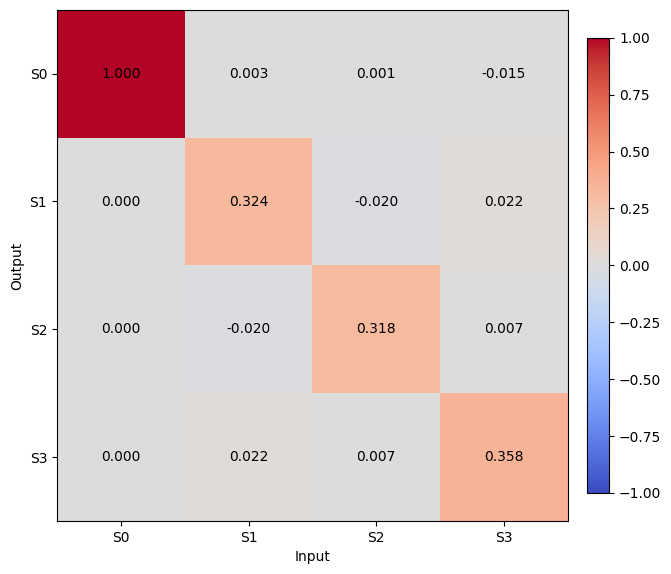

Mueller_sample_20260428_depol_MLEtest_topview.png


In [ ]:
file_name_result = Data_file_name + "_depol_MLEtest"

# Load the 4x4 matrix
csv_path = file_name_result + ".csv"
df = pd.read_csv(csv_path, header=None)
M_t = df.iloc[:4, :4].to_numpy(dtype=float)
M = M_t.T
print("data\n", M)

labels = ["S0", "S1", "S2", "S3"]

fig, ax = plt.subplots(figsize=(7, 6))

# top view heatmap
im = ax.imshow(
    M,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    origin="upper"   # (0,0)을 왼쪽 위로
)

# x, y tick labels
ax.set_xticks(np.arange(4))
ax.set_yticks(np.arange(4))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# axis labels
ax.set_xlabel("Input")
ax.set_ylabel("Output")

# 각 칸에 값 표시
for i in range(4):       # row = y
    for j in range(4):   # col = x
        value = M[i, j]
        ax.text(
            j, i, f"{value:.3f}",
            ha="center",
            va="center",
            color="black"
        )

# colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03)

plt.tight_layout()

out_path = file_name_result + "_topview.png"
# plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(out_path)